In [2]:
import pandas as pd
import numpy as np
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
)

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')
nltk.download('wordnet')

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

[nltk_data] Downloading package stopwords to /home/abdallah-
[nltk_data]     adel/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /home/abdallah-
[nltk_data]     adel/nltk_data...


In [3]:
data = pd.read_csv(r"/home/abdallah-adel/Downloads/dataset/WELFake_Dataset.csv")

print(data.head())
print(data.shape)

   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  
(72134, 4)


In [4]:
display(data.head())
display(data.shape)

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


(72134, 4)

In [5]:
print(data.duplicated().sum())

0


In [6]:
data.drop_duplicates(inplace=True)
print(data.duplicated().sum())

0


In [7]:
data.isnull().sum()

Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data = data.drop(columns=["subject", "date"], errors="ignore")

data.head()

data.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [10]:
data["content"] = data["title"] + " " + data["text"]

data[["content", "label"]].head()

,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
1,NaN,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1


In [11]:
data.isnull().sum()

Unnamed: 0      0
title         558
text           39
label           0
content       597
dtype: int64

In [12]:
print(data["title"].value_counts())

title
Factbox: Trump fills top jobs for his administration                                                        14
Get Ready For Civil Unrest: Survey Finds That Most Americans Are Concerned About Election Violence           8
Highlights: The Trump presidency on April 13 at 9:30 P.M. EDT/0130 GMT on Friday                             8
Factbox: Contenders for senior jobs in Trump's administration                                                8
Michael Moore Owes Me $4.99                                                                                  7
                                                                                                            ..
WIKILEAKS EMAIL SHOWS CLINTON FOUNDATION FUNDS Used For Lavish Wedding Of “Spoiled Brat” Chelsea Clinton     1
Russians steal research on Trump in hack of U.S. Democratic Party                                            1
 WATCH: Giuliani Demands That Democrats Apologize For Trump’s Racist Birtherism                           

In [13]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


nltk.download("stopwords")
nltk.download("wordnet")


stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


data["content"] = data["content"].fillna("")

data["content"] = data["content"].astype(str)

data["content"] = data["content"].str.lower()

data["content"] = data["content"].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

data["content"] = data["content"].apply(lambda x: x.split())

data["content"] = data["content"].apply(lambda words: [word for word in words if word not in stop_words])

data["content"] = data["content"].apply(lambda words: [lemmatizer.lemmatize(word) for word in words])

data["clean_content"] = data["content"].apply(lambda x: " ".join(x))

data[["clean_content", "label"]].head()


[nltk_data] Downloading package stopwords to /home/abdallah-
[nltk_data]     adel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/abdallah-
[nltk_data]     adel/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_content,label
0,law enforcement high alert following threat co...,1
1,,1
2,unbelievable obamas attorney general say charl...,1
3,bobby jindal raised hindu us story christian c...,0
4,satan russia unvelis image terrifying new supe...,1


In [14]:
X = data["clean_content"]
y = data["label"]
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data["clean_content"], y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_text = vectorizer.fit_transform(X_train_text)
X_test_text = vectorizer.transform(X_test_text)

print("Train shape:", X_train_text.shape, " Test shape:", X_test_text.shape)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data["clean_content"], y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_text = vectorizer.fit_transform(X_train_text)
X_test_text = vectorizer.transform(X_test_text)

X_train, X_test = X_train_text, X_test_text

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

print("Train shape:", X_train_text.shape, " Test shape:", X_test_text.shape)

Train shape: (57707, 5000)  Test shape: (14427, 5000)
Train shape: (57707, 5000)  Test shape: (14427, 5000)
Train shape: (57707, 5000)  Test shape: (14427, 5000)


In [15]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVC": LinearSVC(),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = model.decision_function(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_scores),
    })

    fitted_models[name] = (model, y_pred, y_scores)
    print(f"{name} done -> Accuracy: {results[-1]['Accuracy']:.4f}")

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
print("\nModel Comparison:\n", results_df)

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score




# Cross Validation for the best model (Random Forest)
cv_data = data.dropna(subset=["clean_content", "label"]).copy()

cv_data = cv_data[
    cv_data["clean_content"]
    .astype(str)
    .str.strip()
    .ne("")
]

# فحص البيانات
print("Missing texts:", cv_data["clean_content"].isna().sum())
print("Missing labels:", cv_data["label"].isna().sum())
print("Class distribution:")
print(cv_data["label"].value_counts())

# Pipeline
cv_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Stratified Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross Validation
cv_scores = cross_val_score(
    cv_pipeline,
    cv_data["clean_content"],
    cv_data["label"],
    cv=cv,
    scoring="accuracy",
    n_jobs=1,
    error_score="raise"
)

print("\nCross Validation Accuracy:")
print(cv_scores)
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")


/home/abdallah-adel/miniconda3/envs/DEPI/lib/python3.13/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression done -> Accuracy: 0.9502
Multinomial Naive Bayes done -> Accuracy: 0.8492
Linear SVC done -> Accuracy: 0.9555
Passive Aggressive done -> Accuracy: 0.9470
Random Forest done -> Accuracy: 0.9608

Model Comparison:
                      Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0            Random Forest  0.960768   0.951284  0.973588  0.962307  0.994310
1               Linear SVC  0.955500   0.953445  0.960383  0.956901  0.990332
2      Logistic Regression  0.950232   0.948481  0.955127  0.951793  0.988509
3       Passive Aggressive  0.946974   0.944920  0.952432  0.948661  0.986583
4  Multinomial Naive Bayes  0.849172   0.838956  0.874680  0.856445  0.923167
Missing texts: 0
Missing labels: 0
Class distribution:
label
1    36465
0    35028
Name: count, dtype: int64

Cross Validation Accuracy:
[0.96230506 0.95761941 0.96167564 0.96181284 0.9610435 ]
Mean Accuracy: 0.9609
Standard Deviation: 0.0017



Best Model: Random Forest
              precision    recall  f1-score   support

        Fake       0.97      0.95      0.96      7006
        Real       0.95      0.97      0.96      7421

    accuracy                           0.96     14427
   macro avg       0.96      0.96      0.96     14427
weighted avg       0.96      0.96      0.96     14427



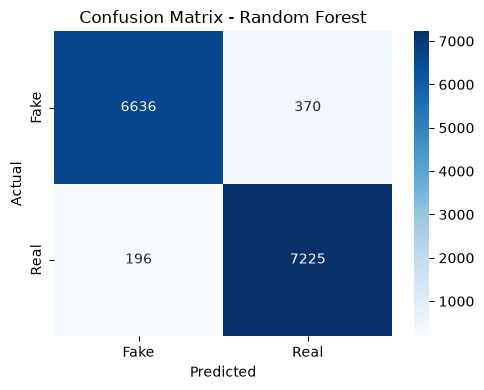

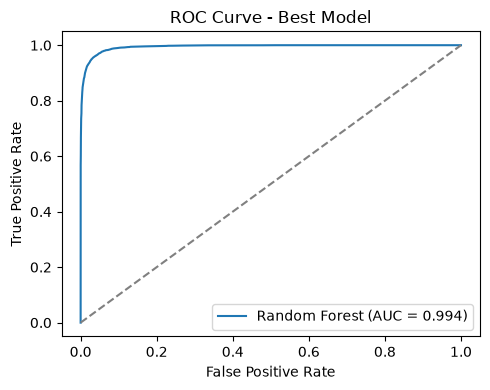

In [16]:
best_model_name = results_df.iloc[0]["Model"]
best_model, best_y_pred, best_y_scores = fitted_models[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(classification_report(y_test, best_y_pred, target_names=["Fake", "Real"]))

# Confusion Matrix
cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_y_scores)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {results_df.iloc[0]['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Model")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()


In [17]:
rf = fitted_models["Random Forest"][0]

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print("Train :", accuracy_score(y_train, train_pred))
print("Test  :", accuracy_score(y_test, test_pred))

Train : 1.0
Test  : 0.9607680044361268


In [18]:
joblib.dump(best_model, "fake_news_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print(f"\nSaved '{best_model_name}' -> fake_news_model.pkl")
print("Saved TF-IDF vectorizer -> tfidf_vectorizer.pkl")


Saved 'Random Forest' -> fake_news_model.pkl
Saved TF-IDF vectorizer -> tfidf_vectorizer.pkl
